In [1]:
!pip install open_clip_torch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score

import open_clip

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
EPOCHS = 50
LR = 3e-4
NUM_CLASSES = 100
EPS = 1e-8

In [15]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)

tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_model = clip_model.to(device)
clip_model.eval()

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [16]:
train_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=clip_preprocess
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=clip_preprocess
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [17]:
classes = test_dataset.classes

prompts = [f"a photo of a {c}" for c in classes]
text_tokens = tokenizer(prompts).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)

W_clip = text_features  # acts like classifier weights

In [18]:
def compute_nc_metrics(features, labels, classifier_weights):
    features = features.cpu().numpy()
    labels = labels.cpu().numpy()
    W = classifier_weights.detach().cpu().numpy()

    K = len(np.unique(labels))

    class_means = []
    for k in range(K):
        class_k = features[labels == k]
        mu_k = np.mean(class_k, axis=0)
        class_means.append(mu_k)

    class_means = np.array(class_means)
    overall_mean = np.mean(features, axis=0)

    Sw = 0.0
    for k in range(K):
        class_k = features[labels == k]
        mu_k = class_means[k]
        Sw += np.sum((class_k - mu_k) ** 2)

    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    M = class_means - overall_mean
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)

    G = M @ M.T
    ETF = np.full((K, K), -1/(K-1))
    np.fill_diagonal(ETF, 1)

    nc2 = np.linalg.norm(G - ETF, ord='fro')

    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    nc3 = np.linalg.norm(W_norm - M, ord='fro')

    return nc1, nc2, nc3


def compute_flatness(features, logits, labels, classifier_weights):
    probs = torch.softmax(logits, dim=1)
    p_y = probs[torch.arange(len(labels)), labels]

    curvature = p_y * (1 - p_y)
    feat_norm = torch.sum(features**2, dim=1)

    trace = torch.mean(feat_norm * curvature)
    weight_norm = torch.sum(classifier_weights**2)

    return (trace / (weight_norm + EPS)).item()

In [19]:
print("\n===== CLIP ZERO-SHOT =====")

all_features, all_labels, all_logits = [], [], []
all_preds, all_labels_list = [], []

correct, total = 0, 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):

        images, labels = images.to(device), labels.to(device)

        features = clip_model.encode_image(images)
        features = features / features.norm(dim=1, keepdim=True)

        logits = features @ W_clip.T
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_features.append(features)
        all_labels.append(labels)
        all_logits.append(logits)

        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

# Metrics
acc = 100 * correct / total
f1_macro = f1_score(all_labels_list, all_preds, average='macro')

all_features = torch.cat(all_features)
all_labels = torch.cat(all_labels)
all_logits = torch.cat(all_logits)

nc1, nc2, nc3 = compute_nc_metrics(all_features, all_labels, W_clip)
flatness = compute_flatness(all_features, all_logits, all_labels, W_clip)

print(f"Acc: {acc:.2f} | F1: {f1_macro:.4f}")
print(f"NC1: {nc1:.4f} | NC2: {nc2:.4f} | NC3: {nc3:.4f}")
print(f"Flatness: {flatness:.6f}")


===== CLIP ZERO-SHOT =====


100%|██████████| 157/157 [00:35<00:00,  4.47it/s]

Acc: 62.15 | F1: 0.6070
NC1: 202.1101 | NC2: 24.6524 | NC3: 12.6392
Flatness: 0.000104


In [20]:
# Freeze CLIP
for param in clip_model.parameters():
    param.requires_grad = False

in_dim = clip_model.visual.output_dim
classifier = nn.Linear(in_dim, NUM_CLASSES).to(device)

optimizer = optim.AdamW(classifier.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [21]:
history = {
    "acc": [], "f1": [],
    "nc1": [], "nc2": [], "nc3": [],
    "flatness": []
}

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1} =====")

    # TRAIN
    classifier.train()
    for images, labels in tqdm(train_loader, desc="Train"):
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            features = clip_model.encode_image(images)
            features = features / features.norm(dim=1, keepdim=True)

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # TEST + METRICS
    classifier.eval()

    all_features, all_labels, all_logits = [], [], []
    all_preds, all_labels_list = [], []

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Test"):

            images, labels = images.to(device), labels.to(device)

            features = clip_model.encode_image(images)
            features = features / features.norm(dim=1, keepdim=True)

            logits = classifier(features)
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_features.append(features)
            all_labels.append(labels)
            all_logits.append(logits)

            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())

    # Compute metrics
    acc = 100 * correct / total
    f1 = f1_score(all_labels_list, all_preds, average='macro')

    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)
    all_logits = torch.cat(all_logits)

    nc1, nc2, nc3 = compute_nc_metrics(
        all_features, all_labels, classifier.weight
    )

    flatness = compute_flatness(
        all_features, all_logits, all_labels, classifier.weight
    )

    # Store
    history["acc"].append(acc)
    history["f1"].append(f1)
    history["nc1"].append(nc1)
    history["nc2"].append(nc2)
    history["nc3"].append(nc3)
    history["flatness"].append(flatness)

    print(f"Acc: {acc:.2f} | F1: {f1:.4f}")
    print(f"NC1: {nc1:.4f} | NC2: {nc2:.4f} | NC3: {nc3:.4f}")
    print(f"Flatness: {flatness:.6f}")


===== Epoch 1 =====


Test: 100%|██████████| 157/157 [00:36<00:00,  4.31it/s]


Acc: 64.06 | F1: 0.6360
NC1: 202.1101 | NC2: 24.6524 | NC3: 5.9979
Flatness: 0.000049

===== Epoch 2 =====


Test: 100%|██████████| 157/157 [00:36<00:00,  4.33it/s]


Acc: 66.18 | F1: 0.6533
NC1: 202.1101 | NC2: 24.6524 | NC3: 5.3275
Flatness: 0.000021

===== Epoch 3 =====


...

Acc: 75.26 | F1: 0.7520
NC1: 202.1101 | NC2: 24.6524 | NC3: 6.2191
Flatness: 0.000001

===== Epoch 49 =====


Test: 100%|██████████| 157/157 [00:36<00:00,  4.32it/s]


Acc: 75.35 | F1: 0.7529
NC1: 202.1101 | NC2: 24.6524 | NC3: 6.2379
Flatness: 0.000001

===== Epoch 50 =====


Test: 100%|██████████| 157/157 [00:36<00:00,  4.31it/s]

Acc: 75.47 | F1: 0.7541
NC1: 202.1101 | NC2: 24.6524 | NC3: 6.2565
Flatness: 0.000001


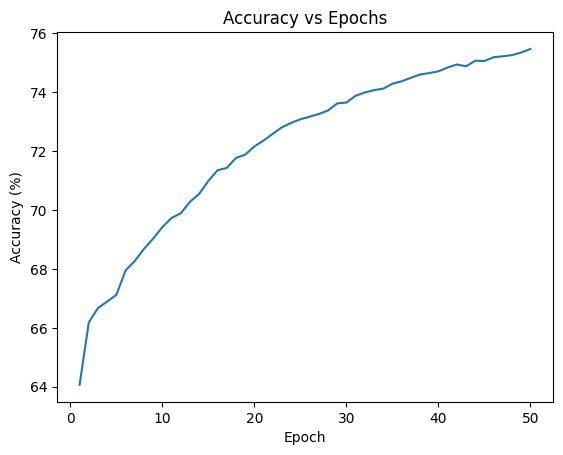

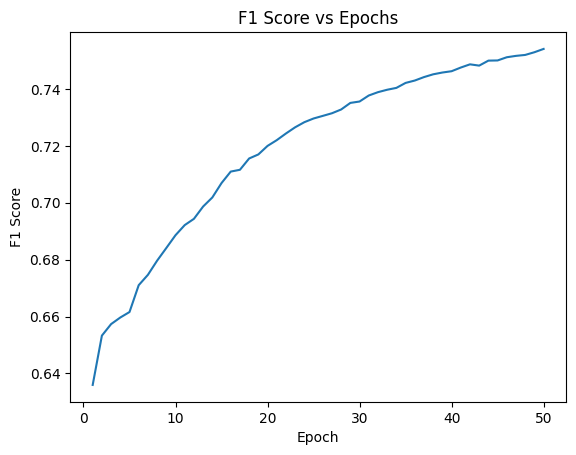

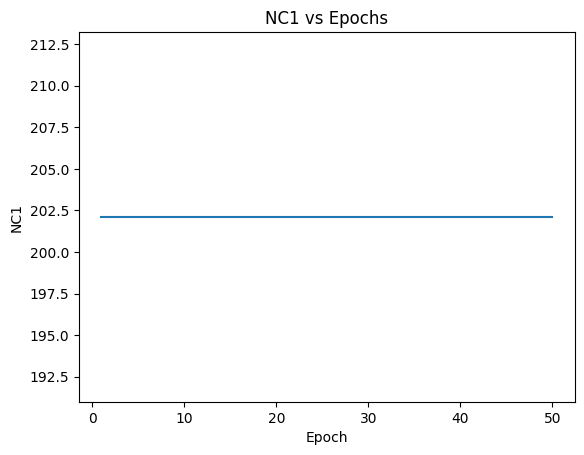

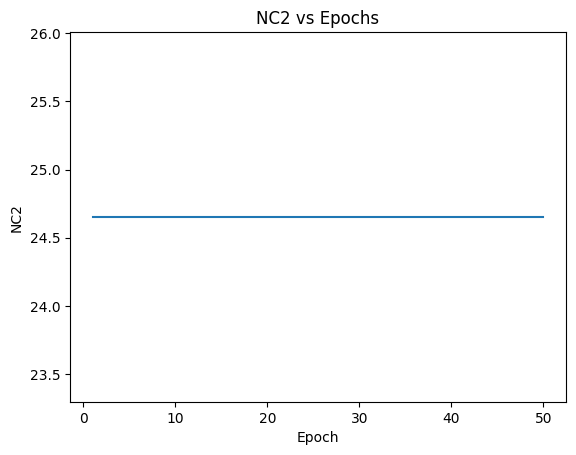

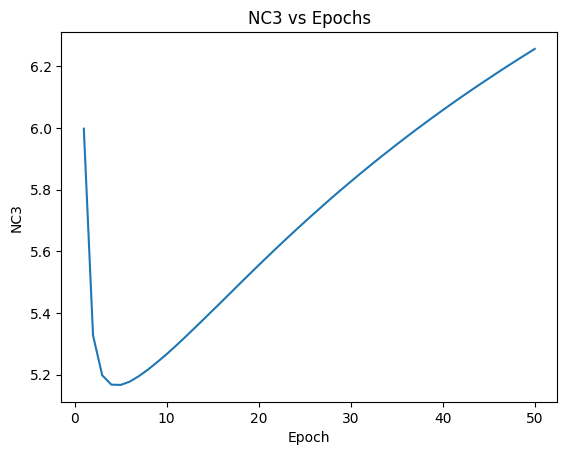

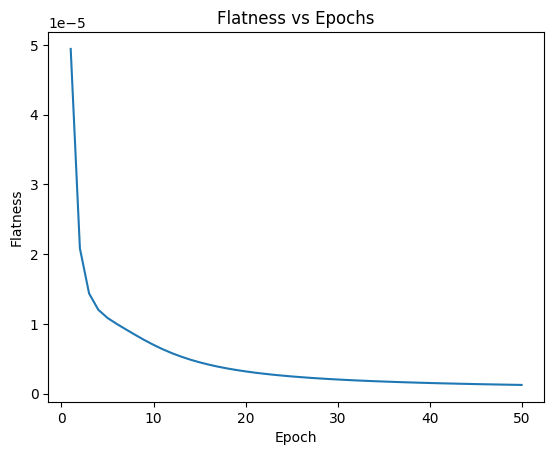

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["acc"]) + 1)

# Accuracy
plt.figure()
plt.plot(epochs, history["acc"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.show()

# F1 Score
plt.figure()
plt.plot(epochs, history["f1"])
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Epochs")
plt.show()

# NC1
plt.figure()
plt.plot(epochs, history["nc1"])
plt.xlabel("Epoch")
plt.ylabel("NC1")
plt.title("NC1 vs Epochs")
plt.show()

# NC2
plt.figure()
plt.plot(epochs, history["nc2"])
plt.xlabel("Epoch")
plt.ylabel("NC2")
plt.title("NC2 vs Epochs")
plt.show()

# NC3
plt.figure()
plt.plot(epochs, history["nc3"])
plt.xlabel("Epoch")
plt.ylabel("NC3")
plt.title("NC3 vs Epochs")
plt.show()

# Flatness
plt.figure()
plt.plot(epochs, history["flatness"])
plt.xlabel("Epoch")
plt.ylabel("Flatness")
plt.title("Flatness vs Epochs")
plt.show()